# Heart Disease Prediction

## Description:

This dataset contains information related to individuals and their risk factors for heart disease. The data includes demographic information such as age and gender, as well as medical history, lifestyle factors, and symptoms associated with heart disease. The target variable indicates whether an individual has been diagnosed with heart disease or not.

## Column Descriptions:

Age: Age of the individual (years). Gender: Gender of the individual (Male/Female). Cholesterol: Cholesterol level in mg/dL. Blood Pressure: Systolic blood pressure in mmHg. Heart Rate: Heart rate in beats per minute. Smoking: Smoking status (Never/Former/Current). Alcohol Intake: Alcohol intake frequency (None/Moderate/Heavy). Exercise Hours: Hours of exercise per week. Family History: Family history of heart disease (Yes/No). Diabetes: Diabetes status (Yes/No). Obesity: Obesity status (Yes/No). Stress Level: Stress level on a scale of 1 to 10. Blood Sugar: Fasting blood sugar level in mg/dL. Exercise Induced Angina: Presence of exercise-induced angina (Yes/No). Chest Pain Type: Type of chest pain experienced (Typical Angina/Atypical Angina/Non-anginal Pain/Asymptomatic). Heart Disease: Target variable indicating presence of heart disease (0: No, 1: Yes).

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

### Data Loading

In [2]:
df = pd.read_csv(r"D:\Downloads\heart_disease_dataset.csv")
df

,Age,Gender,Cholesterol,Blood Pressure,Heart Rate,Smoking,Alcohol Intake,Exercise Hours,Family History,Diabetes,Obesity,Stress Level,Blood Sugar,Exercise Induced Angina,Chest Pain Type,Heart Disease
0,75,Female,228,119,66,Current,Heavy,1,No,No,Yes,8,119,Yes,Atypical Angina,1
1,48,Male,204,165,62,Current,NaN,5,No,No,No,9,70,Yes,Typical Angina,0
2,53,Male,234,91,67,Never,Heavy,3,Yes,No,Yes,5,196,Yes,Atypical Angina,1
3,69,Female,192,90,72,Current,NaN,4,No,Yes,No,7,107,Yes,Non-anginal Pain,0
4,62,Female,172,163,93,Never,NaN,6,No,Yes,No,2,183,Yes,Asymptomatic,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,56,Female,269,111,86,Never,Heavy,5,No,Yes,Yes,10,120,No,Non-anginal Pain,1
996,78,Female,334,145,76,Never,NaN,6,No,No,No,10,196,Yes,Typical Angina,1
997,79,Male,151,179,81,Never,Moderate,4,Yes,No,Yes,8,189,Yes,Asymptomatic,0
998,60,Female,326,151,68,Former,NaN,8,Yes,Yes,No,5,174,Yes,Atypical Angina,1


In [3]:
df.shape

(1000, 16)

In [4]:
df.columns

Index(['Age', 'Gender', 'Cholesterol', 'Blood Pressure', 'Heart Rate',
       'Smoking', 'Alcohol Intake', 'Exercise Hours', 'Family History',
       'Diabetes', 'Obesity', 'Stress Level', 'Blood Sugar',
       'Exercise Induced Angina', 'Chest Pain Type', 'Heart Disease'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Age                      1000 non-null   int64 
 1   Gender                   1000 non-null   object
 2   Cholesterol              1000 non-null   int64 
 3   Blood Pressure           1000 non-null   int64 
 4   Heart Rate               1000 non-null   int64 
 5   Smoking                  1000 non-null   object
 6   Alcohol Intake           660 non-null    object
 7   Exercise Hours           1000 non-null   int64 
 8   Family History           1000 non-null   object
 9   Diabetes                 1000 non-null   object
 10  Obesity                  1000 non-null   object
 11  Stress Level             1000 non-null   int64 
 12  Blood Sugar              1000 non-null   int64 
 13  Exercise Induced Angina  1000 non-null   object
 14  Chest Pain Type          1000 non-null   

In [6]:
df.describe(include='all')

,Age,Gender,Cholesterol,Blood Pressure,Heart Rate,Smoking,Alcohol Intake,Exercise Hours,Family History,Diabetes,Obesity,Stress Level,Blood Sugar,Exercise Induced Angina,Chest Pain Type,Heart Disease
count,1000.000000,1000,1000.000000,1000.0000,1000.000000,1000,660,1000.000000,1000,1000,1000,1000.000000,1000.000000,1000,1000,1000.000000
unique,NaN,2,NaN,NaN,NaN,3,2,NaN,2,2,2,NaN,NaN,2,4,NaN
top,NaN,Female,NaN,NaN,NaN,Never,Heavy,NaN,No,Yes,No,NaN,NaN,No,Non-anginal Pain,NaN
freq,NaN,503,NaN,NaN,NaN,338,346,NaN,501,505,501,NaN,NaN,528,256,NaN
mean,52.293000,NaN,249.939000,135.2810,79.204000,NaN,NaN,4.529000,NaN,NaN,NaN,5.646000,134.941000,NaN,NaN,0.392000
std,15.727126,NaN,57.914673,26.3883,11.486092,NaN,NaN,2.934241,NaN,NaN,NaN,2.831024,36.699624,NaN,NaN,0.488441
min,25.000000,NaN,150.000000,90.0000,60.000000,NaN,NaN,0.000000,NaN,NaN,NaN,1.000000,70.000000,NaN,NaN,0.000000
25%,39.000000,NaN,200.000000,112.7500,70.000000,NaN,NaN,2.000000,NaN,NaN,NaN,3.000000,104.000000,NaN,NaN,0.000000
50%,52.000000,NaN,248.000000,136.0000,79.000000,NaN,NaN,4.500000,NaN,NaN,NaN,6.000000,135.000000,NaN,NaN,0.000000
75%,66.000000,NaN,299.000000,159.0000,89.000000,NaN,NaN,7.000000,NaN,NaN,NaN,8.000000,167.000000,NaN,NaN,1.000000


### Data Cleaning

In [7]:
#Renaming the columns
df.columns = ['Age', 'Gender', 'Cholesterol', 'Blood_Pressure', 'Heart_Rate',
       'Smoking', 'Alcohol_Intake', 'Exercise_Hours', 'Family_History',
       'Diabetes', 'Obesity', 'Stress_Level', 'Blood_Sugar',
       'Exercise_Induced_Angina', 'Chest_Pain_Type', 'Heart_Disease']
df

,Age,Gender,Cholesterol,Blood_Pressure,Heart_Rate,Smoking,Alcohol_Intake,Exercise_Hours,Family_History,Diabetes,Obesity,Stress_Level,Blood_Sugar,Exercise_Induced_Angina,Chest_Pain_Type,Heart_Disease
0,75,Female,228,119,66,Current,Heavy,1,No,No,Yes,8,119,Yes,Atypical Angina,1
1,48,Male,204,165,62,Current,NaN,5,No,No,No,9,70,Yes,Typical Angina,0
2,53,Male,234,91,67,Never,Heavy,3,Yes,No,Yes,5,196,Yes,Atypical Angina,1
3,69,Female,192,90,72,Current,NaN,4,No,Yes,No,7,107,Yes,Non-anginal Pain,0
4,62,Female,172,163,93,Never,NaN,6,No,Yes,No,2,183,Yes,Asymptomatic,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,56,Female,269,111,86,Never,Heavy,5,No,Yes,Yes,10,120,No,Non-anginal Pain,1
996,78,Female,334,145,76,Never,NaN,6,No,No,No,10,196,Yes,Typical Angina,1
997,79,Male,151,179,81,Never,Moderate,4,Yes,No,Yes,8,189,Yes,Asymptomatic,0
998,60,Female,326,151,68,Former,NaN,8,Yes,Yes,No,5,174,Yes,Atypical Angina,1


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isnull().sum()

Age                          0
Gender                       0
Cholesterol                  0
Blood_Pressure               0
Heart_Rate                   0
Smoking                      0
Alcohol_Intake             340
Exercise_Hours               0
Family_History               0
Diabetes                     0
Obesity                      0
Stress_Level                 0
Blood_Sugar                  0
Exercise_Induced_Angina      0
Chest_Pain_Type              0
Heart_Disease                0
dtype: int64

In [10]:
df.isnull().sum()/len(df)*100

Age                         0.0
Gender                      0.0
Cholesterol                 0.0
Blood_Pressure              0.0
Heart_Rate                  0.0
Smoking                     0.0
Alcohol_Intake             34.0
Exercise_Hours              0.0
Family_History              0.0
Diabetes                    0.0
Obesity                     0.0
Stress_Level                0.0
Blood_Sugar                 0.0
Exercise_Induced_Angina     0.0
Chest_Pain_Type             0.0
Heart_Disease               0.0
dtype: float64

In [11]:
df.Alcohol_Intake.unique()

array(['Heavy', nan, 'Moderate'], dtype=object)

In [12]:
df.Alcohol_Intake.mode()[0]

'Heavy'

In [13]:
df["Alcohol_Intake"].fillna(df.Alcohol_Intake.mode()[0],inplace=True)

In [14]:
df.isnull().sum()

Age                        0
Gender                     0
Cholesterol                0
Blood_Pressure             0
Heart_Rate                 0
Smoking                    0
Alcohol_Intake             0
Exercise_Hours             0
Family_History             0
Diabetes                   0
Obesity                    0
Stress_Level               0
Blood_Sugar                0
Exercise_Induced_Angina    0
Chest_Pain_Type            0
Heart_Disease              0
dtype: int64

In [15]:
for i in df.columns:
    print({i:df[i].unique()})

{'Age': array([75, 48, 53, 69, 62, 77, 64, 60, 37, 63, 67, 43, 44, 46, 45, 74, 76,
       58, 31, 66, 79, 32, 41, 36, 57, 72, 65, 28, 70, 51, 54, 52, 38, 25,
       55, 61, 30, 35, 42, 56, 47, 71, 68, 59, 33, 78, 26, 50, 27, 39, 40,
       29, 73, 49, 34])}
{'Gender': array(['Female', 'Male'], dtype=object)}
{'Cholesterol': array([228, 204, 234, 192, 172, 309, 211, 208, 317, 282, 293, 325, 155,
       226, 250, 279, 259, 246, 298, 297, 287, 177, 276, 265, 273, 197,
       319, 313, 179, 227, 262, 311, 230, 306, 216, 189, 162, 207, 271,
       209, 251, 268, 286, 167, 348, 330, 264, 252, 232, 261, 257, 339,
       166, 310, 180, 331, 307, 247, 243, 290, 223, 161, 241, 154, 203,
       205, 184, 291, 210, 215, 336, 242, 320, 284, 249, 248, 236, 174,
       164, 296, 278, 196, 272, 328, 176, 327, 217, 222, 185, 201, 237,
       175, 224, 294, 238, 270, 195, 281, 199, 345, 170, 256, 153, 183,
       347, 221, 200, 277, 302, 169, 329, 266, 198, 308, 283, 254, 343,
       292, 181, 231, 275,

### EDA

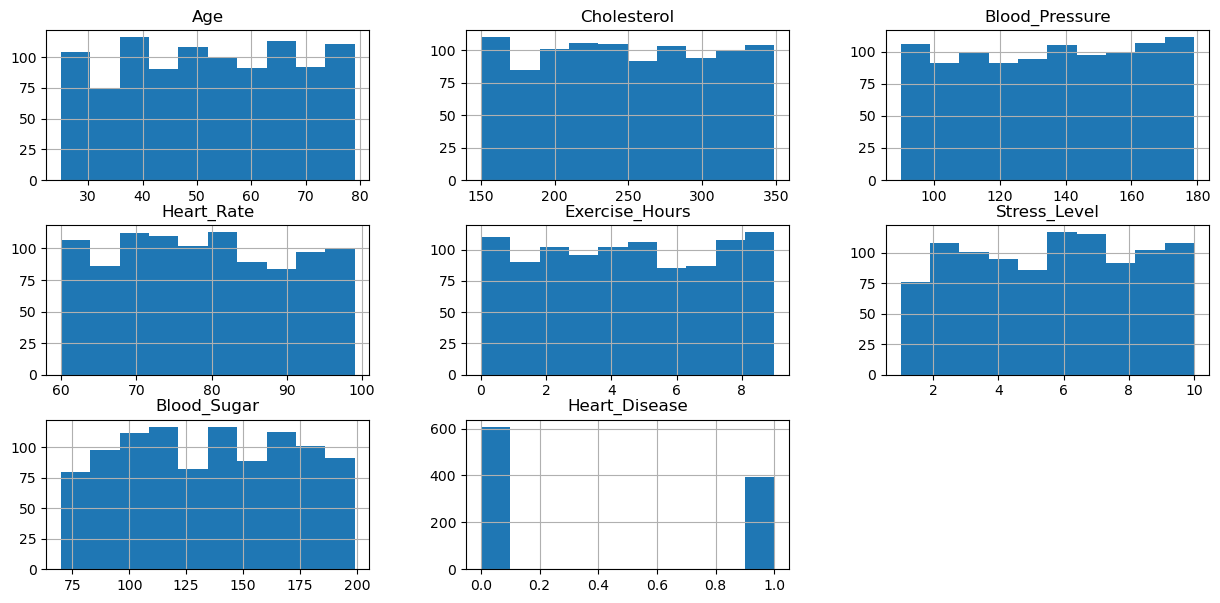

In [16]:
df.hist(figsize=(15, 7));

In [17]:
df.columns

Index(['Age', 'Gender', 'Cholesterol', 'Blood_Pressure', 'Heart_Rate',
       'Smoking', 'Alcohol_Intake', 'Exercise_Hours', 'Family_History',
       'Diabetes', 'Obesity', 'Stress_Level', 'Blood_Sugar',
       'Exercise_Induced_Angina', 'Chest_Pain_Type', 'Heart_Disease'],
      dtype='object')

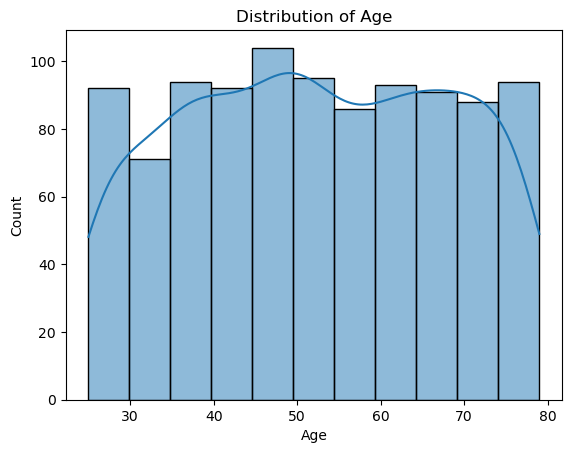

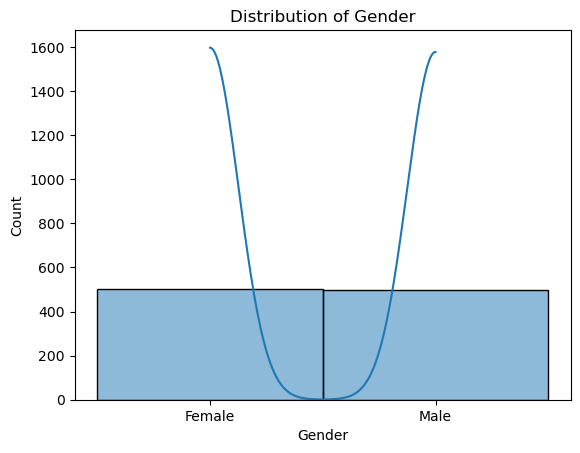

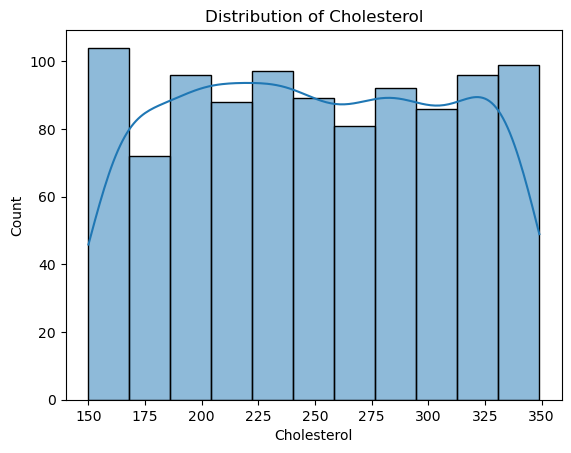

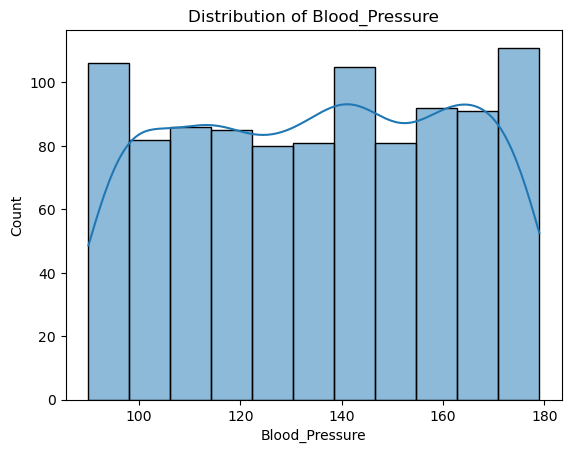

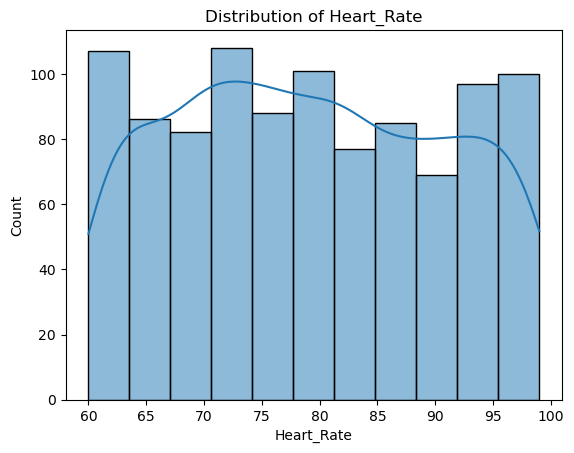

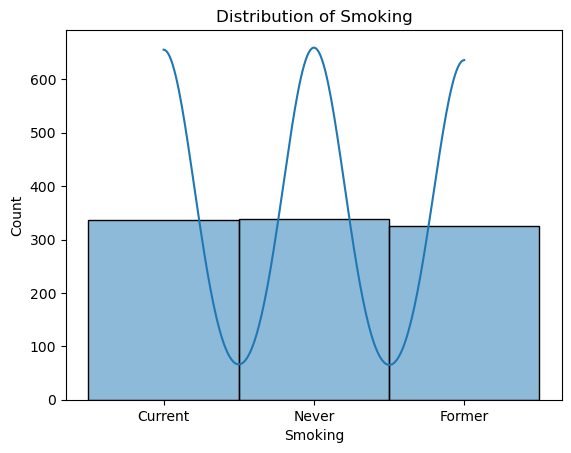

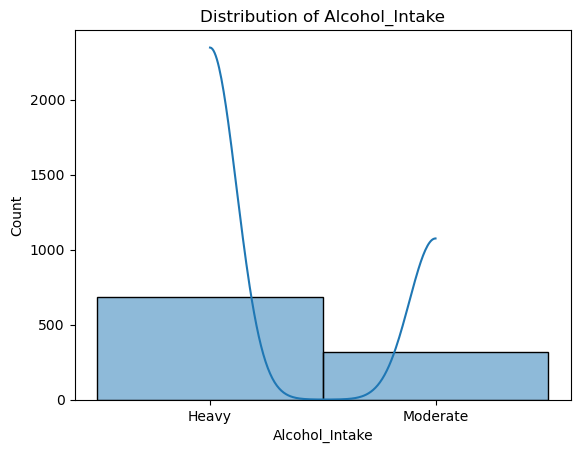

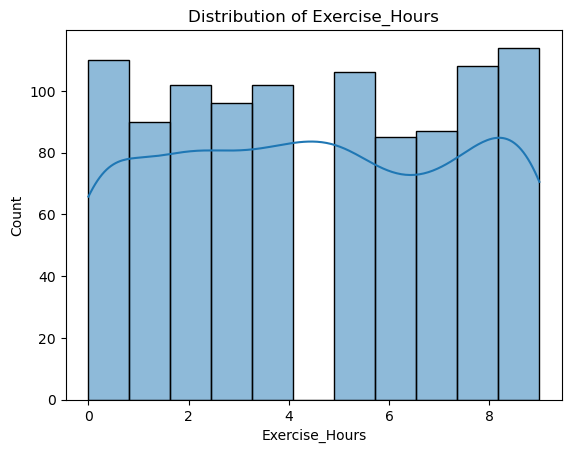

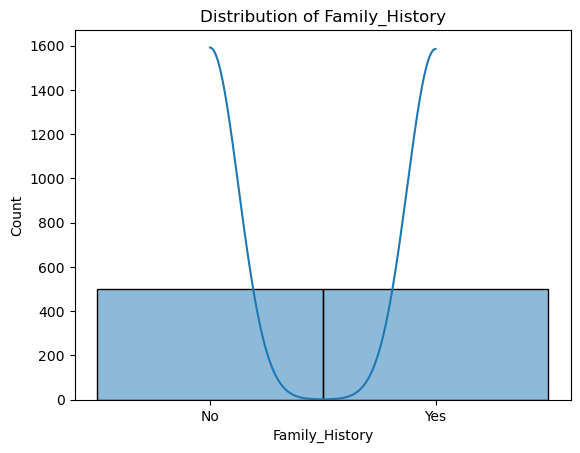

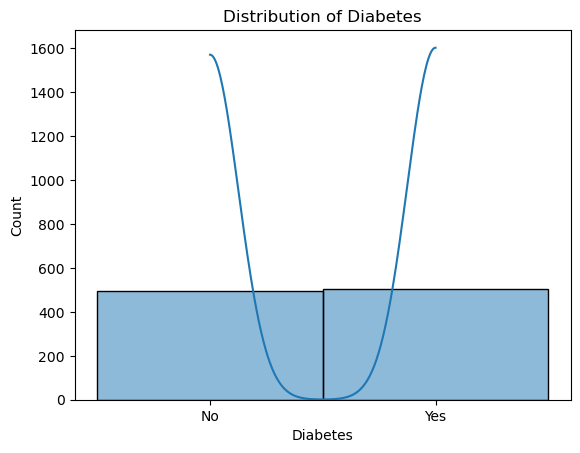

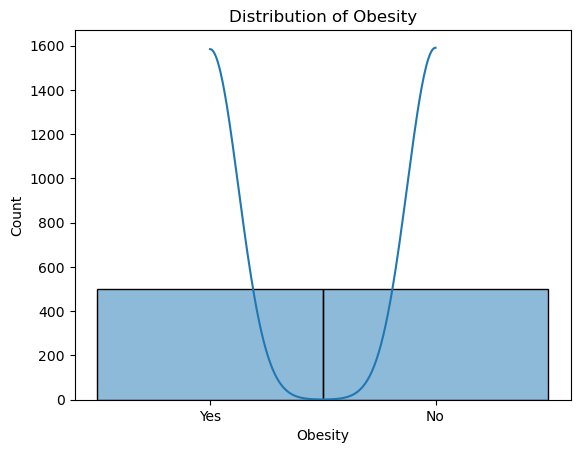

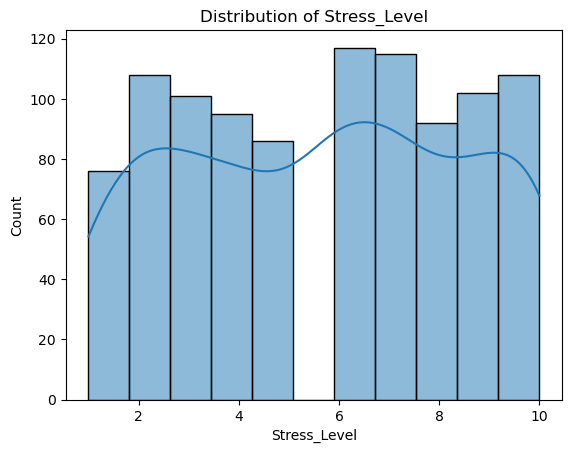

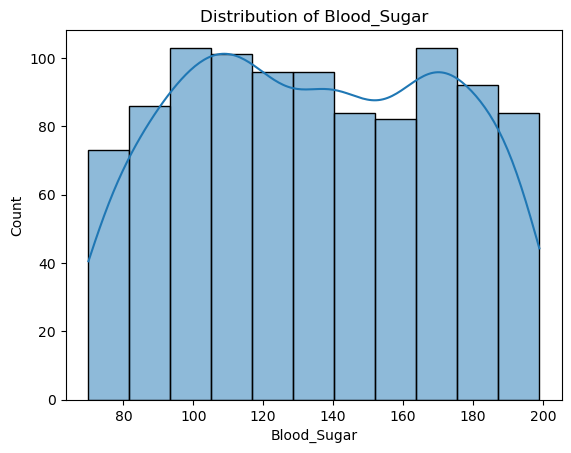

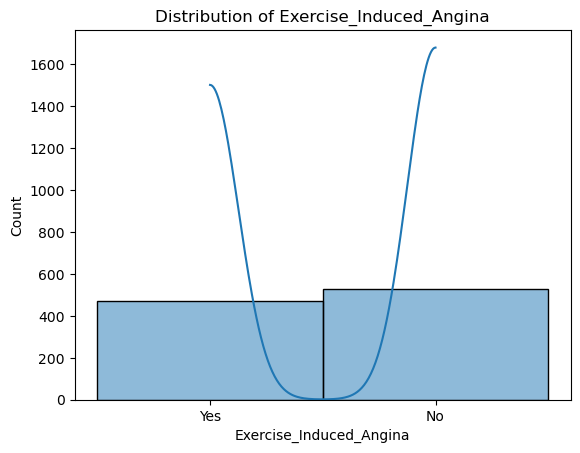

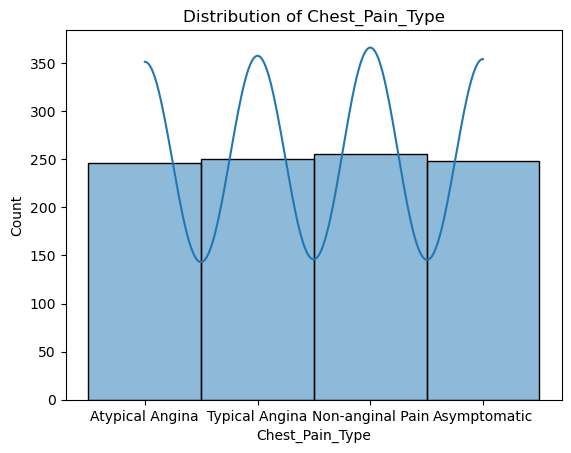

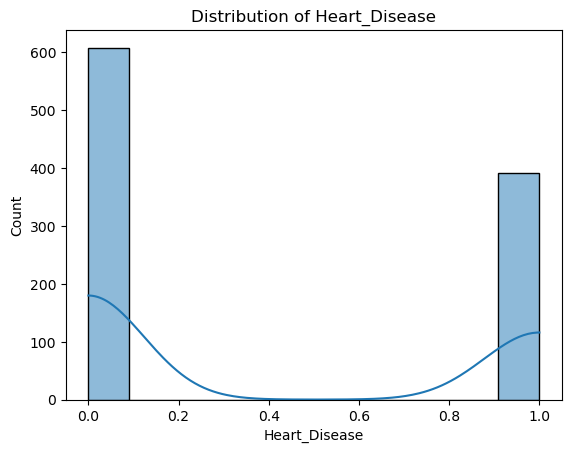

In [18]:
numeric_cols = ['Age', 'Gender', 'Cholesterol', 'Blood_Pressure', 'Heart_Rate',
       'Smoking', 'Alcohol_Intake', 'Exercise_Hours', 'Family_History',
       'Diabetes', 'Obesity', 'Stress_Level', 'Blood_Sugar',
       'Exercise_Induced_Angina', 'Chest_Pain_Type', 'Heart_Disease']

for col in numeric_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

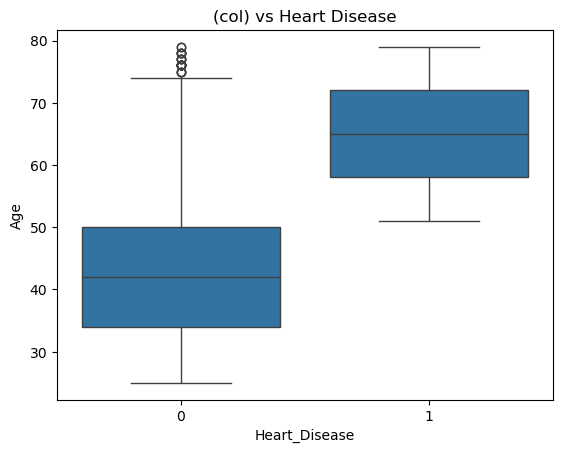

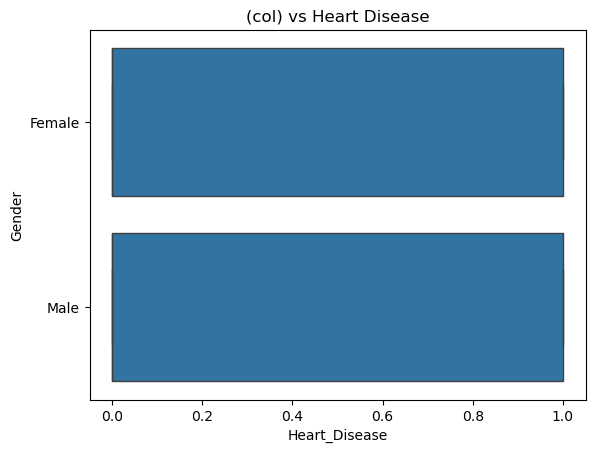

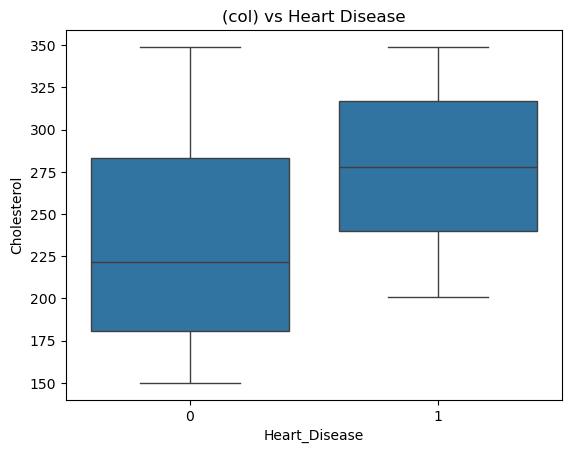

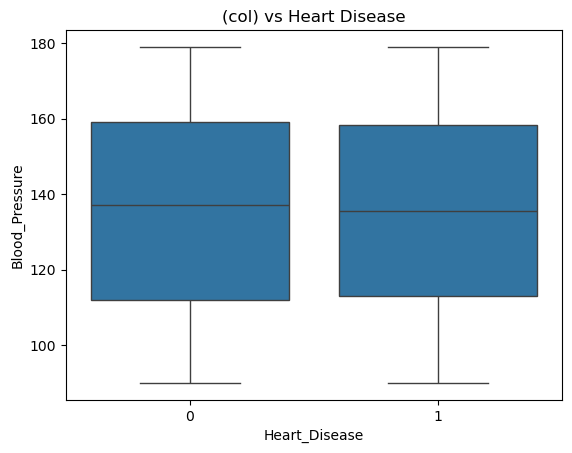

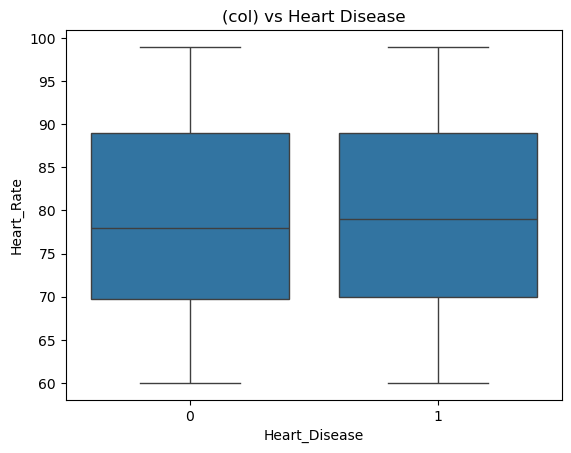

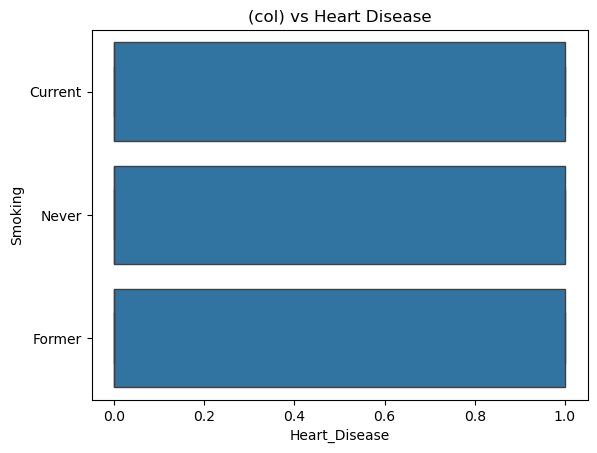

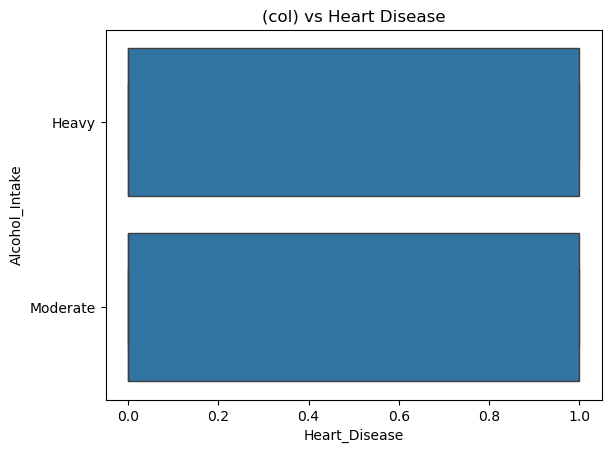

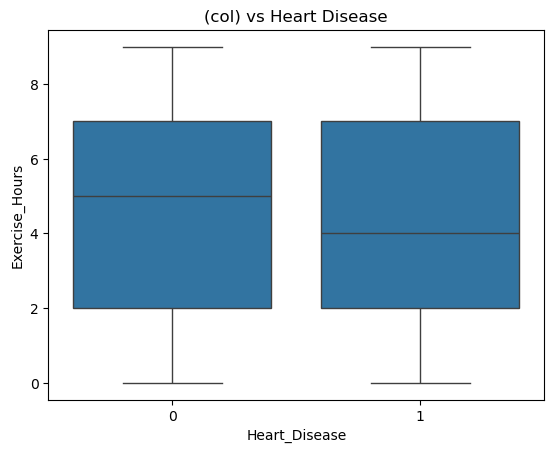

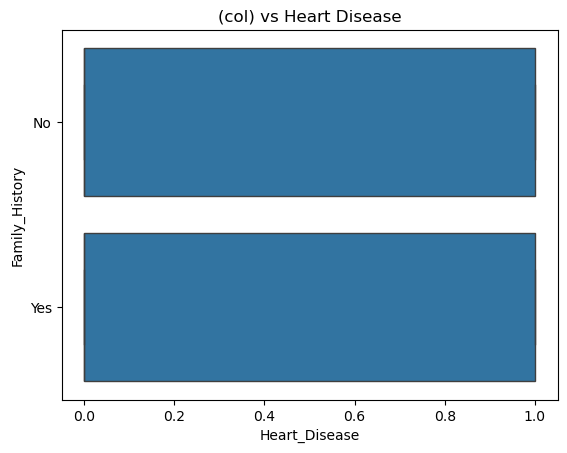

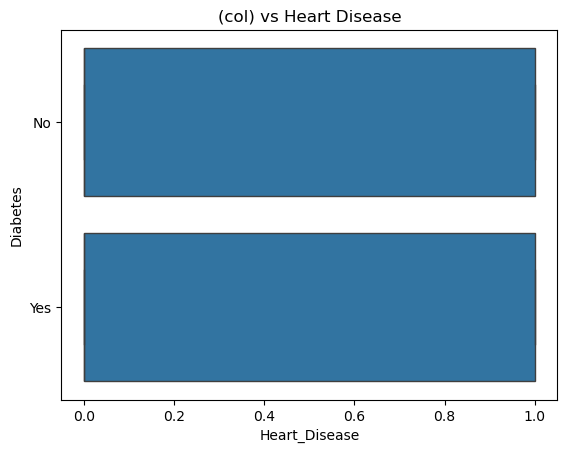

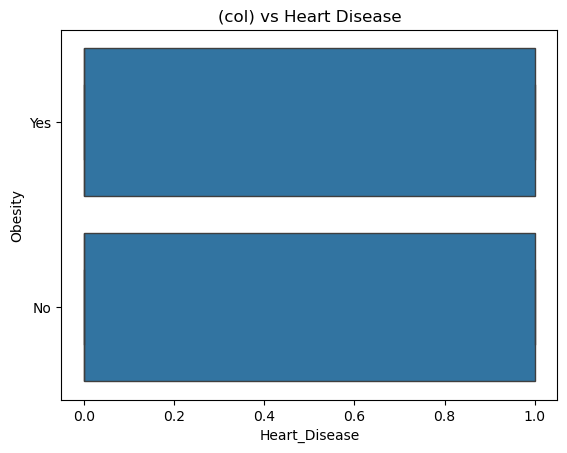

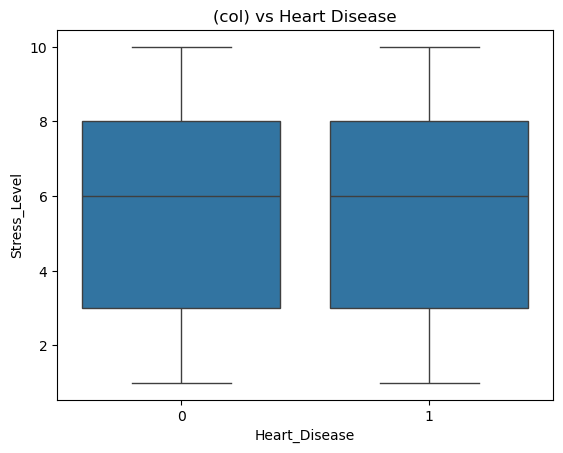

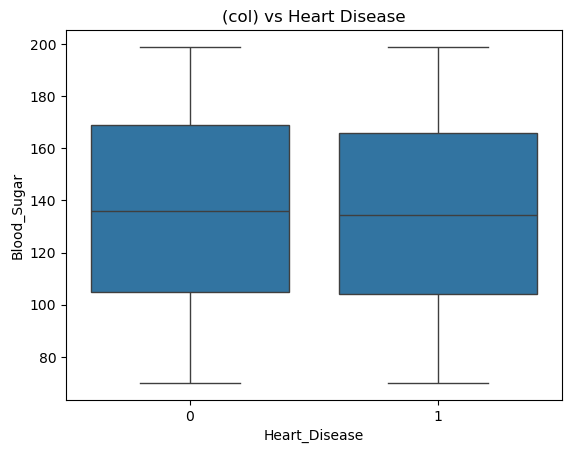

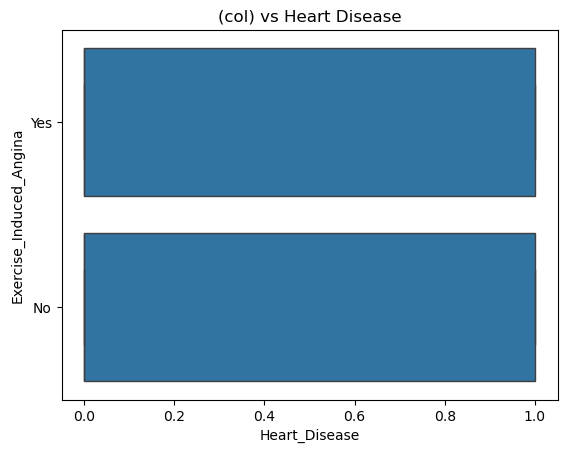

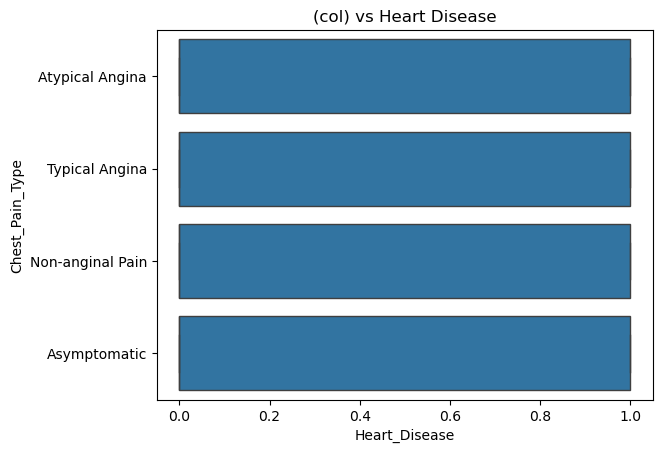

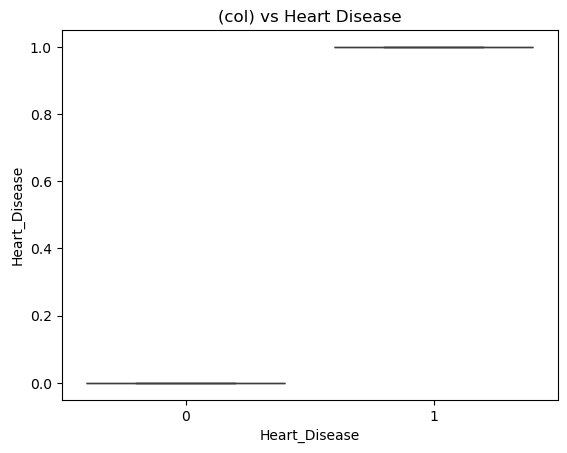

In [19]:
for col in df:
    plt.figure()
    sns.boxplot(data=df, x='Heart_Disease', y=col)
    plt.title(f'(col) vs Heart Disease')
    plt.show();

### Label Encoding

In [20]:
colname = []
for x in df.columns:
    if df[x].dtype == 'object':
        colname.append(x)
colname

['Gender',
 'Smoking',
 'Alcohol_Intake',
 'Family_History',
 'Diabetes',
 'Obesity',
 'Exercise_Induced_Angina',
 'Chest_Pain_Type']

In [21]:
X_features = ['Age', 'Gender', 'Cholesterol', 'Blood_Pressure', 'Heart_Rate',
       'Smoking', 'Alcohol_Intake', 'Exercise_Hours', 'Family_History',
       'Diabetes', 'Obesity', 'Stress_Level', 'Blood_Sugar',
       'Exercise_Induced_Angina', 'Chest_Pain_Type']

In [22]:
# For PreProcessing the Data
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

for x in colname:
    df[x] = le.fit_transform(df[x])
    le_name_mapping = dict(zip(le.classes_ , le.transform(le.classes_)))
    print('Feature' , x)
    print('Mapping' , le_name_mapping)
    print('---------------')

Feature Gender
Mapping {'Female': np.int64(0), 'Male': np.int64(1)}
---------------
Feature Smoking
Mapping {'Current': np.int64(0), 'Former': np.int64(1), 'Never': np.int64(2)}
---------------
Feature Alcohol_Intake
Mapping {'Heavy': np.int64(0), 'Moderate': np.int64(1)}
---------------
Feature Family_History
Mapping {'No': np.int64(0), 'Yes': np.int64(1)}
---------------
Feature Diabetes
Mapping {'No': np.int64(0), 'Yes': np.int64(1)}
---------------
Feature Obesity
Mapping {'No': np.int64(0), 'Yes': np.int64(1)}
---------------
Feature Exercise_Induced_Angina
Mapping {'No': np.int64(0), 'Yes': np.int64(1)}
---------------
Feature Chest_Pain_Type
Mapping {'Asymptomatic': np.int64(0), 'Atypical Angina': np.int64(1), 'Non-anginal Pain': np.int64(2), 'Typical Angina': np.int64(3)}
---------------


In [23]:
le_gender = LabelEncoder()
df["Gender"] = le_gender.fit_transform(df["Gender"])
df.head()

,Age,Gender,Cholesterol,Blood_Pressure,Heart_Rate,Smoking,Alcohol_Intake,Exercise_Hours,Family_History,Diabetes,Obesity,Stress_Level,Blood_Sugar,Exercise_Induced_Angina,Chest_Pain_Type,Heart_Disease
0,75,0,228,119,66,0,0,1,0,0,1,8,119,1,1,1
1,48,1,204,165,62,0,0,5,0,0,0,9,70,1,3,0
2,53,1,234,91,67,2,0,3,1,0,1,5,196,1,1,1
3,69,0,192,90,72,0,0,4,0,1,0,7,107,1,2,0
4,62,0,172,163,93,2,0,6,0,1,0,2,183,1,0,0


In [24]:
le_smoking = LabelEncoder()
df["Smoking"] = le_smoking.fit_transform(df["Smoking"])
df.head()

,Age,Gender,Cholesterol,Blood_Pressure,Heart_Rate,Smoking,Alcohol_Intake,Exercise_Hours,Family_History,Diabetes,Obesity,Stress_Level,Blood_Sugar,Exercise_Induced_Angina,Chest_Pain_Type,Heart_Disease
0,75,0,228,119,66,0,0,1,0,0,1,8,119,1,1,1
1,48,1,204,165,62,0,0,5,0,0,0,9,70,1,3,0
2,53,1,234,91,67,2,0,3,1,0,1,5,196,1,1,1
3,69,0,192,90,72,0,0,4,0,1,0,7,107,1,2,0
4,62,0,172,163,93,2,0,6,0,1,0,2,183,1,0,0


In [25]:
le_alcohol_intake = LabelEncoder()
df["Alcohol_Intake"] = le_alcohol_intake.fit_transform(df["Alcohol_Intake"])

le_family_history = LabelEncoder()
df["Family_History"] = le_family_history.fit_transform(df["Family_History"])

le_diabetes = LabelEncoder()
df["Diabetes"] = le_diabetes.fit_transform(df["Diabetes"])

le_obesity = LabelEncoder()
df["Obesity"] = le_obesity.fit_transform(df["Obesity"])

le_excercise_induced_angina = LabelEncoder()
df["Exercise_Induced_Angina"] = le_excercise_induced_angina.fit_transform(df["Exercise_Induced_Angina"])

le_chest_pain = LabelEncoder()
df["Chest_Pain_Type"] = le_chest_pain.fit_transform(df["Chest_Pain_Type"])


In [26]:
X = df.values[:,0:-1]
Y = df.values[:,-1]

In [27]:
X.shape

(1000, 15)

In [28]:
Y.shape

(1000,)

### Scaling

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X)
X = scaler.transform(X)

#Method-2
#X = scaler.fit_transform(X)
#print(X)

In [30]:
print(X)

[[ 1.4445336  -0.99401789 -0.37900547 ... -0.43458147  1.05765971
  -0.45510944]
 [-0.27310445  1.00601811 -0.79361557 ... -1.77041311  1.05765971
   1.33666001]
 [ 0.04497667  1.00601811 -0.27535294 ...  1.66458253  1.05765971
  -0.45510944]
 ...
 [ 1.6989985   1.00601811 -1.7092129  ...  1.47374944  1.05765971
  -1.35099417]
 [ 0.49029024 -0.99401789  1.31398581 ...  1.06482138  1.05765971
  -0.45510944]
 [ 0.04497667  1.00601811 -0.41355631 ...  0.71041707  1.05765971
  -1.35099417]]


### Running a basic model

In [31]:
from sklearn.model_selection import train_test_split

# Split the data into test and train
X_train , X_test , Y_train , Y_test = train_test_split(X,Y,test_size = 0.2,random_state = 10)

In [32]:
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(800, 15)
(200, 15)
(800,)
(200,)


In [33]:
from sklearn.linear_model import LogisticRegression

# create a model object
classifier = LogisticRegression()

# fitting training data to the model object
classifier.fit(X_train,Y_train)   #input

LogisticRegression()

In [34]:
Y_pred_prob = classifier.predict_proba(X_test)
Y_pred_prob

array([[2.91849622e-01, 7.08150378e-01],
       [8.60640040e-01, 1.39359960e-01],
       [9.43535954e-01, 5.64640463e-02],
       [2.35332617e-01, 7.64667383e-01],
       [7.20413687e-01, 2.79586313e-01],
       [1.22163939e-01, 8.77836061e-01],
       [9.52596283e-01, 4.74037167e-02],
       [9.98450962e-01, 1.54903827e-03],
       [9.19128792e-01, 8.08712082e-02],
       [6.19980435e-02, 9.38001957e-01],
       [7.49814948e-01, 2.50185052e-01],
       [9.63382512e-01, 3.66174885e-02],
       [1.27911726e-02, 9.87208827e-01],
       [9.98488050e-01, 1.51195029e-03],
       [1.02506423e-01, 8.97493577e-01],
       [9.70938408e-01, 2.90615918e-02],
       [9.44834472e-01, 5.51655280e-02],
       [7.35808636e-01, 2.64191364e-01],
       [1.21495108e-01, 8.78504892e-01],
       [5.58026366e-03, 9.94419736e-01],
       [9.97350313e-01, 2.64968707e-03],
       [9.97767082e-01, 2.23291813e-03],
       [1.35760534e-01, 8.64239466e-01],
       [7.71226353e-02, 9.22877365e-01],
       [9.951242

In [35]:
Y_pred = classifier.predict(X_test)
Y_pred

array([1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0,
       0, 1])

In [36]:
print(list(zip(Y_test,Y_pred)))

[(np.int64(1), np.int64(1)), (np.int64(0), np.int64(0)), (np.int64(0), np.int64(0)), (np.int64(1), np.int64(1)), (np.int64(0), np.int64(0)), (np.int64(1), np.int64(1)), (np.int64(0), np.int64(0)), (np.int64(0), np.int64(0)), (np.int64(0), np.int64(0)), (np.int64(1), np.int64(1)), (np.int64(0), np.int64(0)), (np.int64(0), np.int64(0)), (np.int64(1), np.int64(1)), (np.int64(0), np.int64(0)), (np.int64(0), np.int64(1)), (np.int64(0), np.int64(0)), (np.int64(0), np.int64(0)), (np.int64(0), np.int64(0)), (np.int64(1), np.int64(1)), (np.int64(1), np.int64(1)), (np.int64(0), np.int64(0)), (np.int64(0), np.int64(0)), (np.int64(0), np.int64(1)), (np.int64(1), np.int64(1)), (np.int64(0), np.int64(0)), (np.int64(0), np.int64(0)), (np.int64(0), np.int64(0)), (np.int64(1), np.int64(1)), (np.int64(0), np.int64(0)), (np.int64(0), np.int64(0)), (np.int64(1), np.int64(1)), (np.int64(1), np.int64(1)), (np.int64(1), np.int64(1)), (np.int64(0), np.int64(0)), (np.int64(1), np.int64(1)), (np.int64(1), np.in

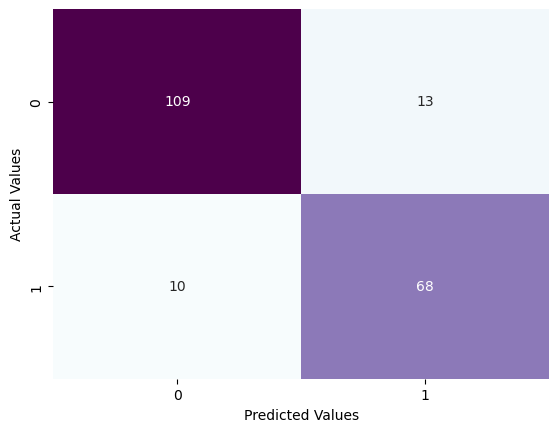

[[109  13]
 [ 10  68]]
Classification report: 
              precision    recall  f1-score   support

           0       0.92      0.89      0.90       122
           1       0.84      0.87      0.86        78

    accuracy                           0.89       200
   macro avg       0.88      0.88      0.88       200
weighted avg       0.89      0.89      0.89       200

Accuracy of the model:  0.885


In [37]:
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report
 
cfm=confusion_matrix(Y_test,Y_pred)
sns.heatmap(cfm , annot=True , fmt='g' , cbar=False , cmap="BuPu")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.show()
print(cfm)
 
print("Classification report: ")
print(classification_report(Y_test,Y_pred))
 
acc=accuracy_score(Y_test, Y_pred)
print("Accuracy of the model: ",acc)

In [38]:
# print the scores on training and test set

print('Training set score: {:.4f}'.format(classifier.score(X_train, Y_train)))

print('Test set score: {:.4f}'.format(classifier.score(X_test, Y_test)))

Training set score: 0.8588
Test set score: 0.8850


### Model Tuning

In [39]:
# store the predicted probabilities
y_pred_prob = classifier.predict_proba(X_test)
y_pred_prob[:,1]

array([7.08150378e-01, 1.39359960e-01, 5.64640463e-02, 7.64667383e-01,
       2.79586313e-01, 8.77836061e-01, 4.74037167e-02, 1.54903827e-03,
       8.08712082e-02, 9.38001957e-01, 2.50185052e-01, 3.66174885e-02,
       9.87208827e-01, 1.51195029e-03, 8.97493577e-01, 2.90615918e-02,
       5.51655280e-02, 2.64191364e-01, 8.78504892e-01, 9.94419736e-01,
       2.64968707e-03, 2.23291813e-03, 8.64239466e-01, 9.22877365e-01,
       4.87575144e-03, 1.53724010e-01, 2.32457129e-03, 5.90086441e-01,
       1.13758187e-01, 6.90921931e-04, 9.61279666e-01, 9.94092773e-01,
       9.48174009e-01, 5.11696345e-03, 9.82342961e-01, 8.75467945e-01,
       1.74005825e-01, 1.06814640e-02, 3.81912804e-02, 9.83804084e-01,
       7.65406269e-01, 9.85611781e-01, 4.22133445e-02, 1.07092267e-03,
       5.57520149e-04, 6.80056983e-02, 9.79012167e-01, 2.86223713e-01,
       7.51020829e-03, 4.74100999e-02, 8.73810102e-01, 5.10516547e-01,
       4.41449824e-01, 2.12119400e-03, 2.23355107e-01, 1.58419721e-02,
      

In [40]:
y_pred_class = []
for value in y_pred_prob [:,1]:
    if value > 0.46:
        y_pred_class.append(1)
    else:
        y_pred_class.append(0)
print(y_pred_class)

[1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1]


### Model Evaluation

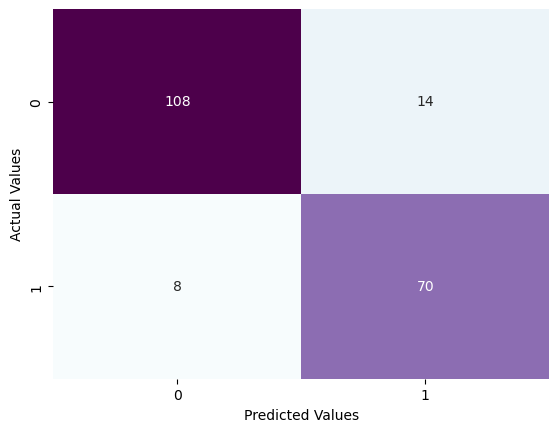

[[108  14]
 [  8  70]]
Classification report: 
              precision    recall  f1-score   support

           0       0.93      0.89      0.91       122
           1       0.83      0.90      0.86        78

    accuracy                           0.89       200
   macro avg       0.88      0.89      0.89       200
weighted avg       0.89      0.89      0.89       200

Accuracy of the model:  0.89


In [41]:
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report
 
cfm=confusion_matrix(Y_test,y_pred_class)
sns.heatmap(cfm , annot=True , fmt='g' , cbar=False , cmap="BuPu")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.show()
print(cfm)
 
print("Classification report: ")
print(classification_report(Y_test,y_pred_class))
 
acc=accuracy_score(Y_test, y_pred_class)
print("Accuracy of the model: ",acc)

In [42]:
# print the scores on training and test set

print('Training set score: {:.4f}'.format(classifier.score(X_train, Y_train)))

print('Test set score: {:.4f}'.format(classifier.score(X_test, Y_test)))

Training set score: 0.8588
Test set score: 0.8850


In [43]:
for a in np.arange(0.4,0.61,0.01):
    predict_mine = np.where(y_pred_prob[:,1] > a, 1, 0)
    cfm=confusion_matrix(Y_test, predict_mine)
    total_err=cfm[0,1]+cfm[1,0]
    print("Errors at threshold ", a, ":",total_err, " , type 2 error :",
          cfm[1,0]," , type 1 error:", cfm[0,1])

Errors at threshold  0.4 : 22  , type 2 error : 7  , type 1 error: 15
Errors at threshold  0.41000000000000003 : 22  , type 2 error : 7  , type 1 error: 15
Errors at threshold  0.42000000000000004 : 22  , type 2 error : 7  , type 1 error: 15
Errors at threshold  0.43000000000000005 : 22  , type 2 error : 7  , type 1 error: 15
Errors at threshold  0.44000000000000006 : 23  , type 2 error : 8  , type 1 error: 15
Errors at threshold  0.45000000000000007 : 22  , type 2 error : 8  , type 1 error: 14
Errors at threshold  0.4600000000000001 : 22  , type 2 error : 8  , type 1 error: 14
Errors at threshold  0.4700000000000001 : 22  , type 2 error : 8  , type 1 error: 14
Errors at threshold  0.4800000000000001 : 22  , type 2 error : 8  , type 1 error: 14
Errors at threshold  0.4900000000000001 : 23  , type 2 error : 10  , type 1 error: 13
Errors at threshold  0.5000000000000001 : 23  , type 2 error : 10  , type 1 error: 13
Errors at threshold  0.5100000000000001 : 23  , type 2 error : 10  , type

### Feature Importance

In [44]:
from sklearn.linear_model import LogisticRegression
import pandas as pd

# Train model
model = LogisticRegression()
model.fit(X_train, Y_train)

# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': df.drop('Heart_Disease', axis=1).columns,
    'Importance': model.coef_[0]
})

# Sort values
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

                    Feature  Importance
0                       Age    2.998989
2               Cholesterol    1.918781
9                  Diabetes    0.199796
8            Family_History    0.144588
7            Exercise_Hours    0.084224
11             Stress_Level    0.076985
1                    Gender    0.061392
13  Exercise_Induced_Angina    0.042669
12              Blood_Sugar    0.037773
4                Heart_Rate    0.035036
6            Alcohol_Intake    0.029373
3            Blood_Pressure   -0.006828
14          Chest_Pain_Type   -0.018195
5                   Smoking   -0.050513
10                  Obesity   -0.075161


## Conclusion:
This project successfully developed a Heart Disease Prediction model using Logistic Regression. After data preprocessing, feature engineering, and model training, the model achieved an accuracy of approximately 89%, demonstrating strong predictive performance. The analysis identified key risk factors such as age, cholesterol level, diabetes, and family history as important contributors to heart disease. Overall, the model can effectively support early risk assessment and assist healthcare professionals in making data-driven decisions for better patient care.